# Mechanistic exploration Attendance model

In [3]:
import sys
sys.path.append('./src')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from Classes.bar import Bar
from Config.config import PATHS
from Classes.cognitive_model_agents import AttendanceM3

In [49]:
free_paramters = {
    'inverse_temperature': 32,
    'bias': 0.4,
    'learning_rate':0.1,
    'len_history':2,
    'delta':1
}
fixed_parameters = {
    'num_agents':4,
    'threshold':0.75
}

In [50]:
bar = Bar(**fixed_parameters)
agent = AttendanceM3(
    free_parameters=free_paramters,
    fixed_parameters=fixed_parameters,
)
agent.number = 0
payoffs = []
attendances = []
probability_go = []
probability_no_go = []
actions = [
# High threshold
    [1, 1, 1, 1, 1, 0, 1, 1, 1],
    [1, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 1, 1, 1, 1, 0, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 0, 1],
]
actions = np.array(actions).T.tolist()
num_rounds = 6

In [51]:
for i in range(num_rounds):
    if i < len(actions):
        decisions = actions[i]
    # Update bar with decisions
    attendance, scores = bar.step(decisions[::-1])
    player_decision = decisions[0]
    # Find payoff
    payoff = agent.payoff(player_decision, decisions)
    payoffs.append(payoff)
    # Find attendances
    print(f"agent.decisions: {agent.decisions}, player_decision: {player_decision}")
    average_go = np.mean(agent.decisions + [player_decision])
    attendances.append(average_go)
    # Update agents with decisions
    agent.update(payoff, decisions)
    print(f"Decision: {player_decision}, Payoff: {payoff}, average_go: {average_go}")
    # Find preference not going
    prob_go = agent.go_probability()
    probability_no_go.append(1 - prob_go)
    probability_go.append(prob_go)


agent.decisions: [], player_decision: 1
Decision: 1, Payoff: 1, average_go: 1.0
agent.decisions: [1], player_decision: 1
Decision: 1, Payoff: 1, average_go: 1.0
agent.decisions: [1, 1], player_decision: 1
Decision: 1, Payoff: 1, average_go: 1.0
agent.decisions: [1, 1, 1], player_decision: 1
Decision: 1, Payoff: -1, average_go: 1.0
agent.decisions: [1, 1, 1, 1], player_decision: 1
Decision: 1, Payoff: 1, average_go: 1.0
agent.decisions: [1, 1, 1, 1, 1], player_decision: 0
Decision: 0, Payoff: 0, average_go: 0.8333333333333334


Text(-0.1, 0.86, 'Pl1')

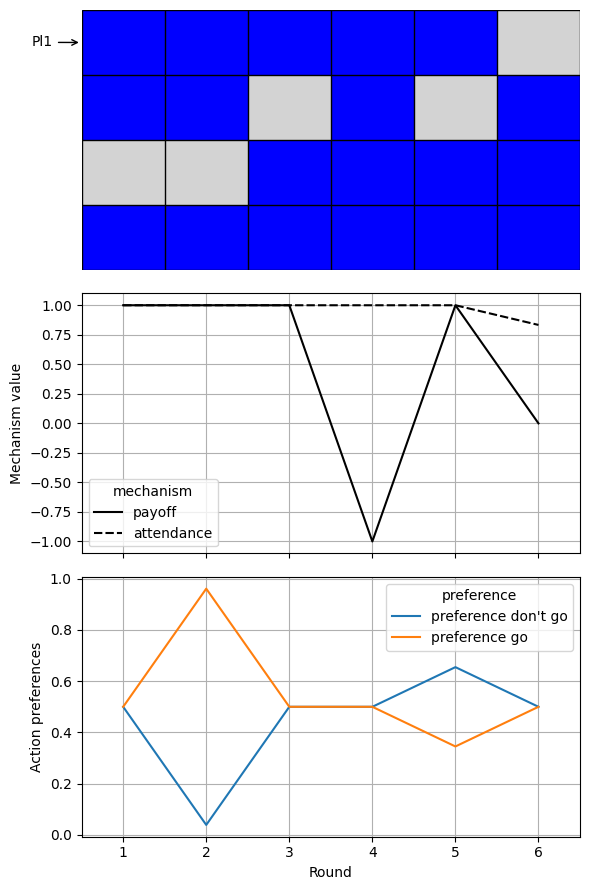

In [52]:
fig, ax = plt.subplots(
    3, 1, 
    figsize=(6,9), 
    tight_layout=True,
)

bar.render(ax=ax[0], num_rounds=num_rounds)

n1, n2 = len(payoffs), len(attendances)
df_values = pd.DataFrame({
    'round': list(range(1, n1 + 1)) + list(range(1, n2 + 1)),
    'value': payoffs + attendances,
    'mechanism': ["payoff"]*n1  + ["attendance"]*n2
})

n1, n2 = len(probability_no_go), len(probability_go)
df_preferences = pd.DataFrame({
    'round': list(range(1, n1 + 1)) + list(range(1, n2 + 1)),
    'value': probability_no_go + probability_go,
    'preference': ["preference don't go"]*n1 + ["preference go"]*n2
})


sns.lineplot(
    x="round", y="value", style="mechanism",
    style_order=["payoff", "attendance"],
    data=df_values, ax=ax[1],
    color='black'
)
ax[1].grid()
ax[1].set_ylabel('Mechanism value')
ax[1].set_xlim([0.5, num_rounds + 0.5])
ax[1].set_xlabel('')
ax[1].set_xticks(range(1, num_rounds + 1)) 
ax[1].set_xticklabels([])

sns.lineplot(
    x="round", y="value", hue="preference",
    hue_order=["preference don't go", "preference go"],
    data=df_preferences, ax=ax[2],
    color='black'
)
ax[2].set_ylabel('Action preferences')

ax[2].set_xlabel('Round')
ax[2].set_xlim([0.5, num_rounds + 0.5])
ax[2].set_xticks(range(1, num_rounds + 1)) 
ax[2].set_xticklabels(range(1, num_rounds + 1))
ax[2].grid()

ax[0].annotate(
    'Pl1',
    xy=(0, 0.875), xycoords='axes fraction',
    xytext=(-0.1, 0.86), textcoords='axes fraction',
    arrowprops=dict(facecolor='black', arrowstyle='->'),
)

In [ ]:
import sys
sys.path.append('../src')

import re
import ast
import pandas as pd

from Config.config import PATHS
from Utils.utils import GetMeasurements
from Utils.interaction import Performer
from Utils.indices import AlternationIndex
from Classes.cognitive_model_agents import *

In [ ]:
path_to_data = PATHS['simulated_data'] / 'optimal_parameters.csv'
optimal_parameters = pd.read_csv(path_to_data)

In [ ]:
def parse_params(s):
    if not isinstance(s, str):
        return s
    # Replace np.float64(x) and np.int64(x) with x
    s = re.sub(r'np\.float64\(([^)]+)\)', r'\1', s)
    s = re.sub(r'np\.int64\(([^)]+)\)', r'\1', s)
    return ast.literal_eval(s)

In [ ]:
MODEL_BY_NAME = {m.name(): m for m in MODELS}

fixed_parameters = {
    'num_agents': 2,
    'threshold': 0.5,
}
simulation_parameters = {
    'num_rounds': 10,
    'num_episodes': 10,
    'verbose': False
}

df_list =[] 
for idx, row in optimal_parameters.iterrows():
    if row['model'].startswith('Priors'):
        continue
    model_class = MODEL_BY_NAME[row['model']]
    free_parameters = parse_params(row['params'])
    df = Performer.sim(
        agent_class=model_class,
        fixed_parameters=fixed_parameters,
        free_parameters=free_parameters,
        simulation_parameters=simulation_parameters
    )
    df_list.append(df)

df = pd.concat(df_list, ignore_index=True)
df.head(2)


,id_sim,round,attendance,id_player,decision,score,model,threshold,num_agents
0,1b8f33a6-232e-11f1-a48a-b5d0ad9dae1a,0,"[1, 0]",0,1,1,,0.5,2
1,1b8f33a6-232e-11f1-a48a-b5d0ad9dae1a,0,"[1, 0]",1,0,0,,0.5,2


In [ ]:
gm = GetMeasurements(
    data=df, 
    measures=[
        'efficiency', 'inequality',
        'bounded_efficiency', 
        'entropy', 'conditional_entropy', 
        'conditional_entropy_2nd_order', 'min_entropy'
    ],
    normalize=True,
)
data = gm.get_measurements()
index_gen = AlternationIndex.from_file(priority='mlp')
data['inequality'] = index_gen(data)
data.head(2)

Exception: Error: No column data found. Should be one of "id_sim", "room", or "group".
Columns found: Index(['round', 'attendance', 'id_player', 'decision', 'score'], dtype='str')